Есакова Елизавета Михайловна

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
import re, string, random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter, defaultdict

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
ROOT_PATH = "/content/drive/MyDrive/text/laba1/corpus.txt"

try:
    from google.colab import drive
    drive.mount('/content/drive')
except:
    print("Google Drive уже смонтирован или монтирование не требуется.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Я взяла "Преступление и наказание" Ф.М.Достоевского

In [ ]:
def load_text(filepath):
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            return f.read()
    except FileNotFoundError:
        print(f"Файл не найден: {filepath}")
        return None
    except UnicodeDecodeError:
        with open(filepath, 'r', encoding='latin-1') as f:
            return f.read()

text = load_text(ROOT_PATH)

print(f" {len(text)} символов")

 1077332 символов


### Часть 1 - Токенизация и статистика (30%)

1. Выберите любой текст на русском или английском языке объёмом не менее 5 000 слов. Можно взять:
   - Любую книгу из открытых источников (например, [Lib.ru](http://lib.ru)).

2. В Python выполните **токенизацию двумя способами**:
   - Разбивка по пробелам: `text.split()`.
   - С помощью `nltk.word_tokenize()` (обрабатывает пунктуацию и сокращения грамотнее).
   
   Выведите первые 20 токенов каждым способом. Чем они различаются?

3. Приведите все токены к нижнему регистру и удалите знаки пунктуации.

4. Подсчитайте:
   - Общее число токенов (N).
   - Число уникальных токенов - размер словаря (V).
   - Топ-20 самых частых слов. Выведите в виде таблицы и постройте столбчатый график.

5. Постройте **график Ципфа**: по оси X - логарифм ранга слова, по оси Y - логарифм его частоты. Почему получается именно такой график? Что это говорит о языке?

---

In [ ]:
# по пробелам
tokens_split = text.split()

# с нлтк
tokens_nltk = nltk.word_tokenize(text)

print("По пробелу:", tokens_split[:20])

print("С нлтк:", tokens_nltk[:20])

По пробелу: ['Федор', 'Михайлович', 'Достоевский', 'Преступление', 'и', 'наказание', 'Часть', 'первая', 'I', 'В', 'начале', 'июля,', 'в', 'чрезвычайно', 'жаркое', 'время,', 'под', 'вечер,', 'один', 'молодой']
С нлтк: ['Федор', 'Михайлович', 'Достоевский', 'Преступление', 'и', 'наказание', 'Часть', 'первая', 'I', 'В', 'начале', 'июля', ',', 'в', 'чрезвычайно', 'жаркое', 'время', ',', 'под', 'вечер']


Различия:
*   при рвзбивке по пробелам, она разбивает только по пробелам, пропуская пунктуацию и сокращения
*   с нлтк пунктуацию выносят в отдельный токен(в тексте выше видно, что запятые вынесены отдельно

In [ ]:
def normalize(tokens):
    return [t.lower() for t in tokens if t not in string.punctuation and t.strip()]

tokens_clean = normalize(tokens_nltk)

Общее число токенов: 174662

Размер словаря: 25813
   Слово  Частота
0      и     8452
1     не     3779
2      в     3726
3    что     3215
4     он     2852
5     на     2407
6      я     2395
7    ...     2097
8      с     2006
9      а     1777
10   как     1622
11   это     1386
12   его     1189
13   так     1171
14    но     1155
15    же     1130
16    да     1055
17    вы      969
18   всё      953
19     к      917


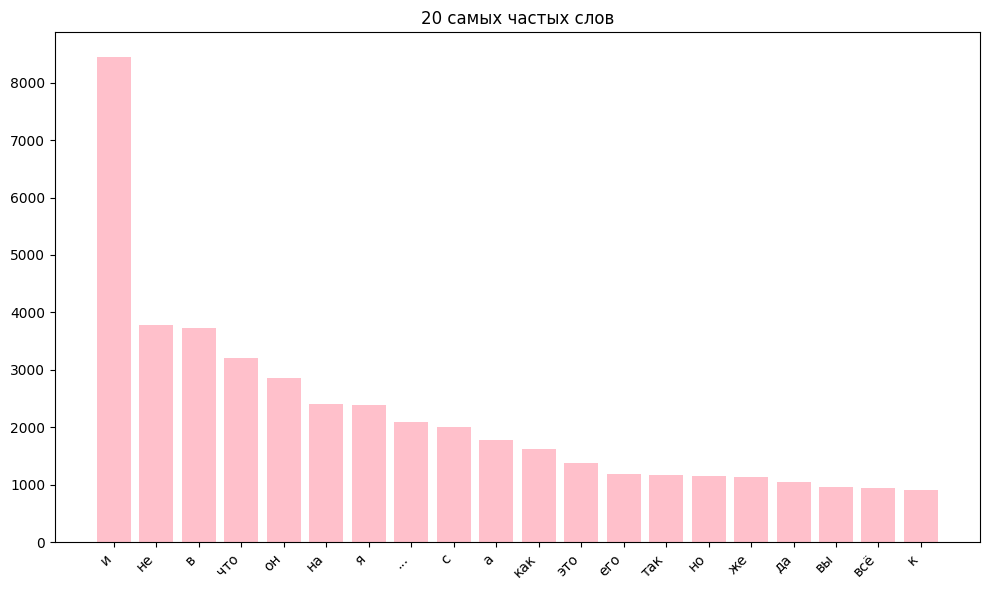

In [ ]:
N = len(tokens_clean)
V = len(set(tokens_clean))
freq = Counter(tokens_clean)
dvacat = freq.most_common(20)

print(f"Общее число токенов: {N}\n")
print(f"Размер словаря: {V}")

df = pd.DataFrame(dvacat, columns=['Слово', 'Частота'])
print(df)

plt.figure(figsize=(10, 6))
plt.bar([w for w, _ in dvacat], [c for _, c in dvacat], color='pink')
plt.xticks(rotation=45, ha='right')
plt.title('20 самых частых слов')
plt.tight_layout()
plt.show()

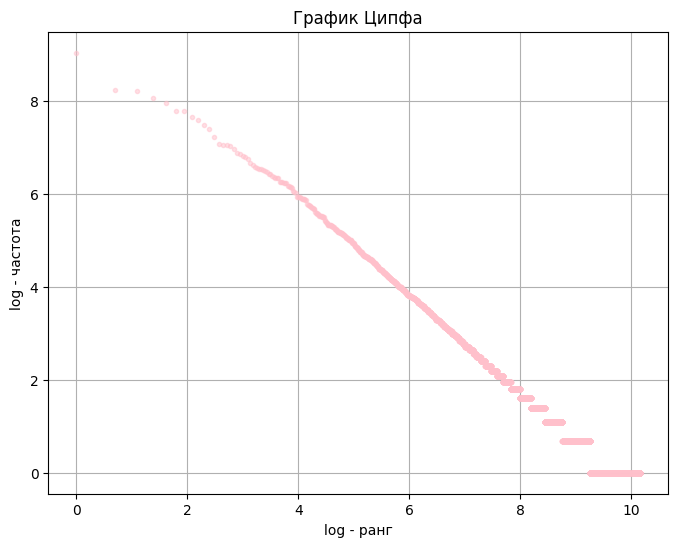

In [ ]:
# cортируем частоты по убыванию
sorted_freq = sorted(freq.values(), reverse=True)
ranks = np.arange(1, len(sorted_freq) + 1)

plt.figure(figsize=(8, 6))
plt.plot(np.log(ranks), np.log(sorted_freq), '.', alpha=0.5, color='pink')
plt.xlabel('log - ранг')
plt.ylabel('log - частота')
plt.title('График Ципфа')
plt.grid(True)
plt.show()

# Частота слова обратно пропорциональна его рангу в частотном словаре

# График закона Ципфа получается резко убывающим, переходящим в длинный «хвост» с низкой частотой, из-за структуры естественного языка и информационных систем, где очень немногие элементы встречаются чрезвычайно часто, а большинство элементов - крайне редко. Это показывает, что язык подчиняется степенному закону распределения: мало очень частых слов и огромное количество редких.

Ссылка на википедию со статьей, по которой я разбиралась в работе этого закона:

https://ru.wikipedia.org/wiki/%D0%97%D0%B0%D0%BA%D0%BE%D0%BD_%D0%A6%D0%B8%D0%BF%D1%84%D0%B0


---

### Часть 2 - Редакционное расстояние (30%)

6. Реализуйте функцию `edit_distance(s1, s2)`, которая вычисляет **минимальное редакционное расстояние (расстояние Левенштейна)** между двумя строками. Разрешены три операции: вставка, удаление, замена - каждая стоит 1.

   Алгоритм основан на динамическом программировании: заполните матрицу размером `(len(s1)+1) × (len(s2)+1)`.
   
   > Подсказка: ячейка `dp[i][j]` означает стоимость преобразования первых `i` символов строки `s1` в первые `j` символов строки `s2`. Ответ находится в правом нижнем углу матрицы.

7. Проверьте реализацию на примерах:
   - `"кот"` → `"кот"` (ожидается 0)
   - `"кот"` → `"код"` (ожидается 1)
   - `"мама"` → `"рама"` (ожидается 1)
   - `"intention"` → `"execution"` (ожидается 5)
   - Добавьте ещё 6 пар слов на своё усмотрение
   
   Для каждой пары распечатайте итоговую матрицу.

8. **Применение - исправление опечаток:** возьмите слово с опечаткой (например, `"алгоритмм"` или `"нейроная"`). По словарю из вашего корпуса (Часть 1) найдите 5 слов с наименьшим редакционным расстоянием. Выведите их. Работает ли метод на практике?

---

Как работает edit_distance:

Если буквы слов совпали, то делать ничего не нужно. берём значение из клетки по диагонали сверху слева

Если же буквы не совпадают, смотрим на три соседние клетки(слева, слева верхний угол, и верхняя над нашей) и выбираем ту, где число меньше всего, к нему добавляем 1 и вносим как значение нашей клетки


*   dp[i][j] -  стоимость превращения  первых i символов s1 в первые j символов s2

по итогу правый нижний угол равен числу изменений которое нам надо сделать в исходном слове, то есть и есть редакционное расстояние

In [ ]:
def edit_distance(s1, s2):
    m, n = len(s1), len(s2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(
                    dp[i-1][j],
                    dp[i][j-1],
                    dp[i-1][j-1]
                )
    return dp, dp[m][n]

def print_matrix(dp, s1, s2):
    m, n = len(s1), len(s2)
    header = "      " + "  ".join(f"{c:>3}" for c in " " + s2)
    print(header)
    print("    " + "-" * (4 * (n + 1) + 1))
    for i, row in enumerate(dp):
        ch = " " if i == 0 else s1[i-1]
        line = f"{ch:>3} |" + "".join(f"{val:>4}" for val in row)
        print(line)
    print()

In [ ]:
test_pairs = [
    ("кот", "кот"),
    ("кот", "код"),
    ("мама", "рама"),
    ("intention", "execution"),
    ("двфу", "фефу"),
    ("матрица", "мать"),
    ("привет", "пока"),
    ("слон", "кулон"),
    ("обработка", "обработкa"),  # тут английская буква a в конце слова
    ("dog", "hotdog")
]

for s1, s2 in test_pairs:
    dp, dist = edit_distance(s1, s2)
    print(f"'{s1}' - '{s2}': расстояние = {dist} \n")
    print("Матрица:")
    print_matrix(dp, s1, s2)

'кот' - 'кот': расстояние = 0 

Матрица:
             к    о    т
    -----------------
    |   0   1   2   3
  к |   1   0   1   2
  о |   2   1   0   1
  т |   3   2   1   0

'кот' - 'код': расстояние = 1 

Матрица:
             к    о    д
    -----------------
    |   0   1   2   3
  к |   1   0   1   2
  о |   2   1   0   1
  т |   3   2   1   1

'мама' - 'рама': расстояние = 1 

Матрица:
             р    а    м    а
    ---------------------
    |   0   1   2   3   4
  м |   1   1   2   2   3
  а |   2   2   1   2   2
  м |   3   3   2   1   2
  а |   4   4   3   2   1

'intention' - 'execution': расстояние = 5 

Матрица:
             e    x    e    c    u    t    i    o    n
    -----------------------------------------
    |   0   1   2   3   4   5   6   7   8   9
  i |   1   1   2   3   4   5   6   6   7   8
  n |   2   2   2   3   4   5   6   7   7   7
  t |   3   3   3   3   4   5   5   6   7   8
  e |   4   3   4   3   4   5   6   6   7   8
  n |   5   4   4   4   4   5   

In [ ]:
def suggest_corrections(misspelled, vocabulary, top_k=5):
    candidates = []
    vocab_list = list(vocabulary)
    for i, word in enumerate(vocab_list):
        _, dist = edit_distance(misspelled, word)
        candidates.append((word, dist))
    candidates.sort(key=lambda x: x[1])
    return candidates[:top_k]

vocab = set(tokens_clean)
typo = "матреца"
print(f"Поиск слов с наименьшим редакционным расстоянием для слова: '{typo}'\n")
suggestions = suggest_corrections(typo, vocab)
print(f"Варианты: {suggestions}")

Поиск слов с наименьшим редакционным расстоянием для слова: 'матреца'

Варианты: [('матери', 3), ('хитрецы', 3), ('марфа', 3), ('матерей', 3), ('митрей', 3)]


In [ ]:
#Также взяла слово из текста и написала его с опечаткой, чтобы оно точно было в моем словаре

typo2 = "иступлении"
print(f"Поиск слов с наименьшим редакционным расстоянием для слова: '{typo2}' \n")
suggestions2 = suggest_corrections(typo2, vocab)
print(f"Варианты: {suggestions2}")

Поиск слов с наименьшим редакционным расстоянием для слова: 'иступлении' 

Варианты: [('исступлении', 1), ('исступление', 2), ('исступлений', 2), ('исступления', 2), ('изумлении', 3)]


# При проверки метода по исправлению опечаток на практике можно сделать вывод, что успешность метода зависит от размера словаря. Как у меня изначально полчилось - правильно слово не было найдено, потому что его нет в моем словаре. Также полный перебор всего словаря занимает много времени, что не подойдет для больших словарей.

---

### Часть 3 - N-граммовые языковые модели (40%)

9. Разделите корпус на обучающую (80%) и тестовую (20%) части.

10. На обучающей части постройте **биграммную языковую модель**:
    - Подсчитайте частоты всех биграмм (пар соседних слов).
    - Вычислите условные вероятности: P(w_n | w_{n−1}) = count(w_{n−1}, w_n) / count(w_{n−1}).

11. Примените **сглаживание Лапласа (add-1)**:

    P_laplace(w_n | w_{n−1}) = (count(w_{n−1}, w_n) + 1) / (count(w_{n−1}) + V)

    Объясните в двух предложениях: зачем нужно сглаживание? Что происходит без него, если в тесте встречается биграмм, которого не было в обучении?

12. **Генерация текста:** используя биграммную модель, сгенерируйте 3 предложения длиной 10–15 слов. Начните с любого частого слова, на каждом шаге выбирайте следующее слово случайно с учётом вероятностей. Оцените качество генерации на глаз.

13. **Перплексия:** вычислите перплексию биграммной модели (со сглаживанием Лапласа) на тестовой части:

    PP(W) = P(w_1, w_2, ..., w_N)^(−1/N)

    Чем меньше перплексия - тем лучше модель понимает текст. Сравните перплексию биграммной и триграммной модели. Объясните результат.

**Последний шаг:** постройте **график зависимости перплексии от размера обучающей выборки** (10%, 25%, 50%, 80% от корпуса). Что происходит с качеством модели при увеличении данных?

---

In [ ]:
random.seed(2)  # соответствует моему номеру в списке
tokens_shuffled = tokens_clean.copy()
random.shuffle(tokens_shuffled)

split_idx = int(len(tokens_shuffled) * 0.8)
train = tokens_shuffled[:split_idx]
test = tokens_shuffled[split_idx:]

print(f"Обучающая: {len(train)} токенов")
print(f"Тестовая часть: {len(test)} токенов")

Обучающая: 139729 токенов
Тестовая часть: 34933 токенов


N-грамма - это последовательность из N слов. Модель оценивает вероятность появления слова на основе предыдущих (N-1) слов.

Биграмма (n=2): P(w_n | w_{n−1})
Триграмма (n=3): P(w_n | w_{n−2}, w_{n−1})

Подсчёт вероятностей:

P(w_n | w_{n−1}) = count(w_{n−1}, w_n) / count(w_{n−1})

In [ ]:
def _ngram_model(tokens, n=2):
    ngrams = defaultdict(Counter)
    for i in range(len(tokens) - n + 1):
        context = tuple(tokens[i:i+n-1])
        next_word = tokens[i+n-1]
        ngrams[context][next_word] += 1
    return ngrams

bigram_model = _ngram_model(train, n=2)

In [ ]:
print("Примеры биграмм:\n")
all_bigrams = Counter()
for ctx, counter in bigram_model.items():
    for w, c in counter.items():
        all_bigrams[ctx + (w,)] = c

for (w1, w2), c in all_bigrams.most_common(10):
    ctx_count = sum(bigram_model[(w1,)].values())
    prob = c / ctx_count
    print(f"  P('{w2}' | '{w1}') = {c}/{ctx_count} = {prob:.6f}")

Примеры биграмм:

  P('и' | 'и') = 323/6785 = 0.047605
  P('в' | 'и') = 161/6785 = 0.023729
  P('и' | 'не') = 157/3001 = 0.052316
  P('не' | 'и') = 153/6785 = 0.022550
  P('и' | 'в') = 140/2964 = 0.047233
  P('и' | 'что') = 121/2578 = 0.046936
  P('что' | 'и') = 117/6785 = 0.017244
  P('и' | 'он') = 115/2321 = 0.049548
  P('он' | 'и') = 101/6785 = 0.014886
  P('я' | 'и') = 98/6785 = 0.014444




P_laplace(w_n | w_{n−1}) = (count(w_{n−1}, w_n) + 1) / (count(w_{n−1}) + V)

In [ ]:
def get_probability(context, word, model, vocab_size, alpha=1):
    count_context = sum(model[context].values())
    count_bigram = model[context].get(word, 0)
    return (count_bigram + alpha) / (count_context + alpha * vocab_size)

V = len(set(train))  # размер словаря

Сглаживание Лапласа нужно, чтобы избежать нулевых вероятностей для невиденных ранее n-грамм, что позволяет модели работать с редкими и новыми сочетаниями слов. Без него, если в тесте встретится биграмма, отсутствующая в обучении, вероятность всей последовательности станет 0, и перплексия обратится в бесконечность(деление на ноль)

In [ ]:
def generate_text(model, start_word, length, vocab, vocab_size):
    text = [start_word]
    for _ in range(length - 1):
        context = (text[-1],)
        probs = {w: get_probability(context, w, model, vocab_size) for w in vocab}
        next_word = random.choices(list(probs.keys()), weights=probs.values())[0]
        text.append(next_word)
    return ' '.join(text)

vocab_set = set(train)
for i in range(3):
    start = random.choice([w for w, c in freq.most_common(50) if w in vocab_set])
    length = random.randint(10, 15)
    sentence = generate_text(bigram_model, start, length, vocab_set, V)
    print(f"  {i+1}. {sentence}")

  1. не старику ступал ненавистно соседнего предположите полубессмысленная частных нужная прилаживалась хмелю золотопромышленность
  2. да щенке видели принятых огляделся пошло мягким глупенькое припас меньше
  3. он пряталась отворенной вспоминать лежал свечей мальчики домашним слабенькая обнаружили разбитое чем-нибудь


На каждом шаге вычисляем вероятности всех возможных следующих слов (с учётом сглаживания) и случайно выбираем следующее слово пропорционально вероятностям

Качество такого недотекста невысокое: текст грамматически не связан, скачки между темами. Биграммная модель запоминает локальные переходы, но не структуру предложения.

**Преплексия** - мера того, насколько хорошо модель предсказывает текст. Чем меньше перплексия, тем лучше модель.

In [ ]:
def perplexity(model, test_tokens, vocab_size, n=2):
    N = len(test_tokens)
    log_prob_sum = 0
    for i in range(N - n + 1):
        context = tuple(test_tokens[i:i+n-1])
        word = test_tokens[i+n-1]
        prob = get_probability(context, word, model, vocab_size)
        log_prob_sum += np.log(prob)
    return np.exp(-log_prob_sum / N)

pp_bi = perplexity(bigram_model, test, V, n=2)
print(f"Перплексия биграммной модели: {pp_bi:.2f}")

Перплексия биграммной модели: 13922.47


In [ ]:
trigram_model = _ngram_model(train, n=3)
pp_tri = perplexity(trigram_model, test, V, n=3)
print(f"Перплексия триграммной модели: {pp_tri:.2f}")

Перплексия триграммной модели: 22213.15


Триграммная модель показала худший результат - высокую перплексию. Это получилось из-за того, что количество триграмм экспоненциально больше числа биграмм. На имеющемся словаре текста большинство триграмм встретились крайне редко, и из-за этого при применении сглаживания Лапласа (add-1) компонента V (размер словаря) в знаменателе стала доминировать над реальной частотой встречаемости. Это привело к тому, что распределение вероятностей стало почти равномерным.
Когда модель присваивает почти одинаковые вероятности всем словам, то она перестает различать, какое слово подходит лучше и её перплексия возрастает до максимума.

Перплексия биграмной модели ниже, потому что для неё данных хватило, чтобы лучше выучить устойчивые связи.

Зависимость перплексии от объёма данных: 

  Размер: 10% - Перплексия: 4797.88
  Размер: 25% - Перплексия: 8142.42
  Размер: 50% - Перплексия: 11427.28
  Размер: 80% - Перплексия: 13922.47


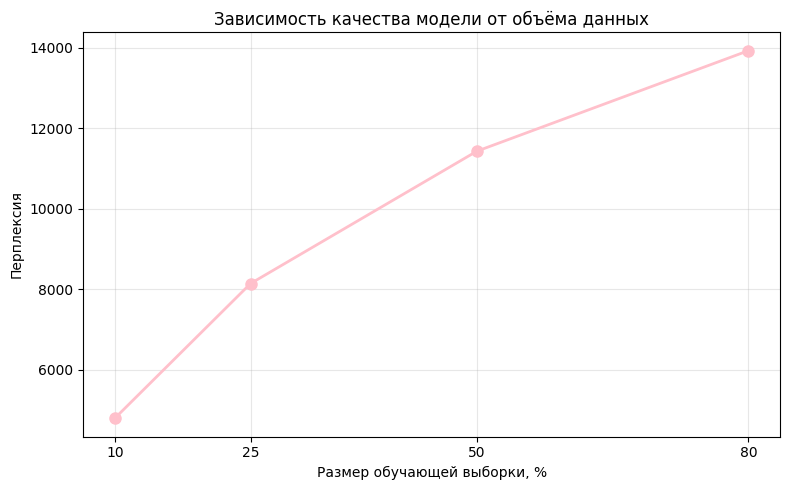

In [ ]:
sizes = [0.1, 0.25, 0.5, 0.8]
results = []

print("Зависимость перплексии от объёма данных: \n")
for frac in sizes:
    split = int(len(tokens_shuffled) * frac)
    train_sub = tokens_shuffled[:split]
    V_sub = len(set(train_sub))
    model_sub = _ngram_model(train_sub, n=2)
    pp = perplexity(model_sub, test, V_sub, n=2)
    results.append((frac, pp))
    print(f"  Размер: {frac*100:.0f}% - Перплексия: {pp:.2f}")

plt.figure(figsize=(8, 5))
plt.plot([f*100 for f, _ in results], [pp for _, pp in results], 'o-', color='pink', linewidth=2, markersize=8)
plt.xlabel('Размер обучающей выборки, %')
plt.ylabel('Перплексия')
plt.title('Зависимость качества модели от объёма данных')
plt.grid(True, alpha=0.3)
plt.xticks([10, 25, 50, 80])
plt.tight_layout()
plt.show()

Я думала, что перплексия будет снижаться с ростом данных (модель видит больше контекстов), но на графике видно обратное. Это может быть связано с тем, что при увеличении данных растёт размер словаря V, что усиливает эффект сглаживания Лапласа и размывает вероятности